In [ ]:
import imfusion as imf
from imfusion import vision
import numpy as np
from matplotlib import pyplot as plt
import pathlib

## a. Load samples images.
For this example we are going to compute optical flow between two images. 

In [7]:
# Loading the same stereo pair as stereo_reconstruction demo for simplicity. 

# Initialize a SharedImageSet which is going to hold the images as a sequence of frames. 

image_set = imf.SharedImageSet() 
first_image_path = pathlib.Path("data/stereo_left.png")
first_image = imf.load(str(first_image_path))[0]

second_image_path = pathlib.Path("data/stereo_right.png")
second_image = imf.load(str(second_image_path))[0]

image_set.add(first_image[0])
image_set.add(second_image[0])
# The above two lines will estimate flow of first_image -> second_image.
image_set.add(first_image[0])
# Adding first_image again which will let us compute flow for second_image -> first_image.
# You can add arbitrarly more frames here if needed. 

print(image_set)

imfusion.SharedImageSet(size: 3, [
    imfusion.SharedImage(UBYTE width: 710 height: 496 channels: 3),
    imfusion.SharedImage(UBYTE width: 710 height: 496 channels: 3),
    imfusion.SharedImage(UBYTE width: 710 height: 496 channels: 3)
])


## b. Computation

In [ ]:
# # Machine learning approach from https://arxiv.org/abs/2003.12039
# params = vision.OpticalFlowRAFTSettings()
# flow_result, _ = vision.estimate_optical_flow(image_set, params)

# An improvement over the above Machine learning approach giving flow uncertainty as output (https://arxiv.org/abs/2405.14793):
params = vision.OpticalFlowSEARAFTSettings() 
flow_result, flow_uncertainty = vision.estimate_optical_flow(image_set, params)
print(flow_result)
print(flow_uncertainty)

imfusion.SharedImageSet(size: 2, [
    imfusion.SharedImage(FLOAT width: 710 height: 496 channels: 2),
    imfusion.SharedImage(FLOAT width: 710 height: 496 channels: 2)
])
imfusion.SharedImageSet(size: 2, [
    imfusion.SharedImage(FLOAT width: 710 height: 496),
    imfusion.SharedImage(FLOAT width: 710 height: 496)
])


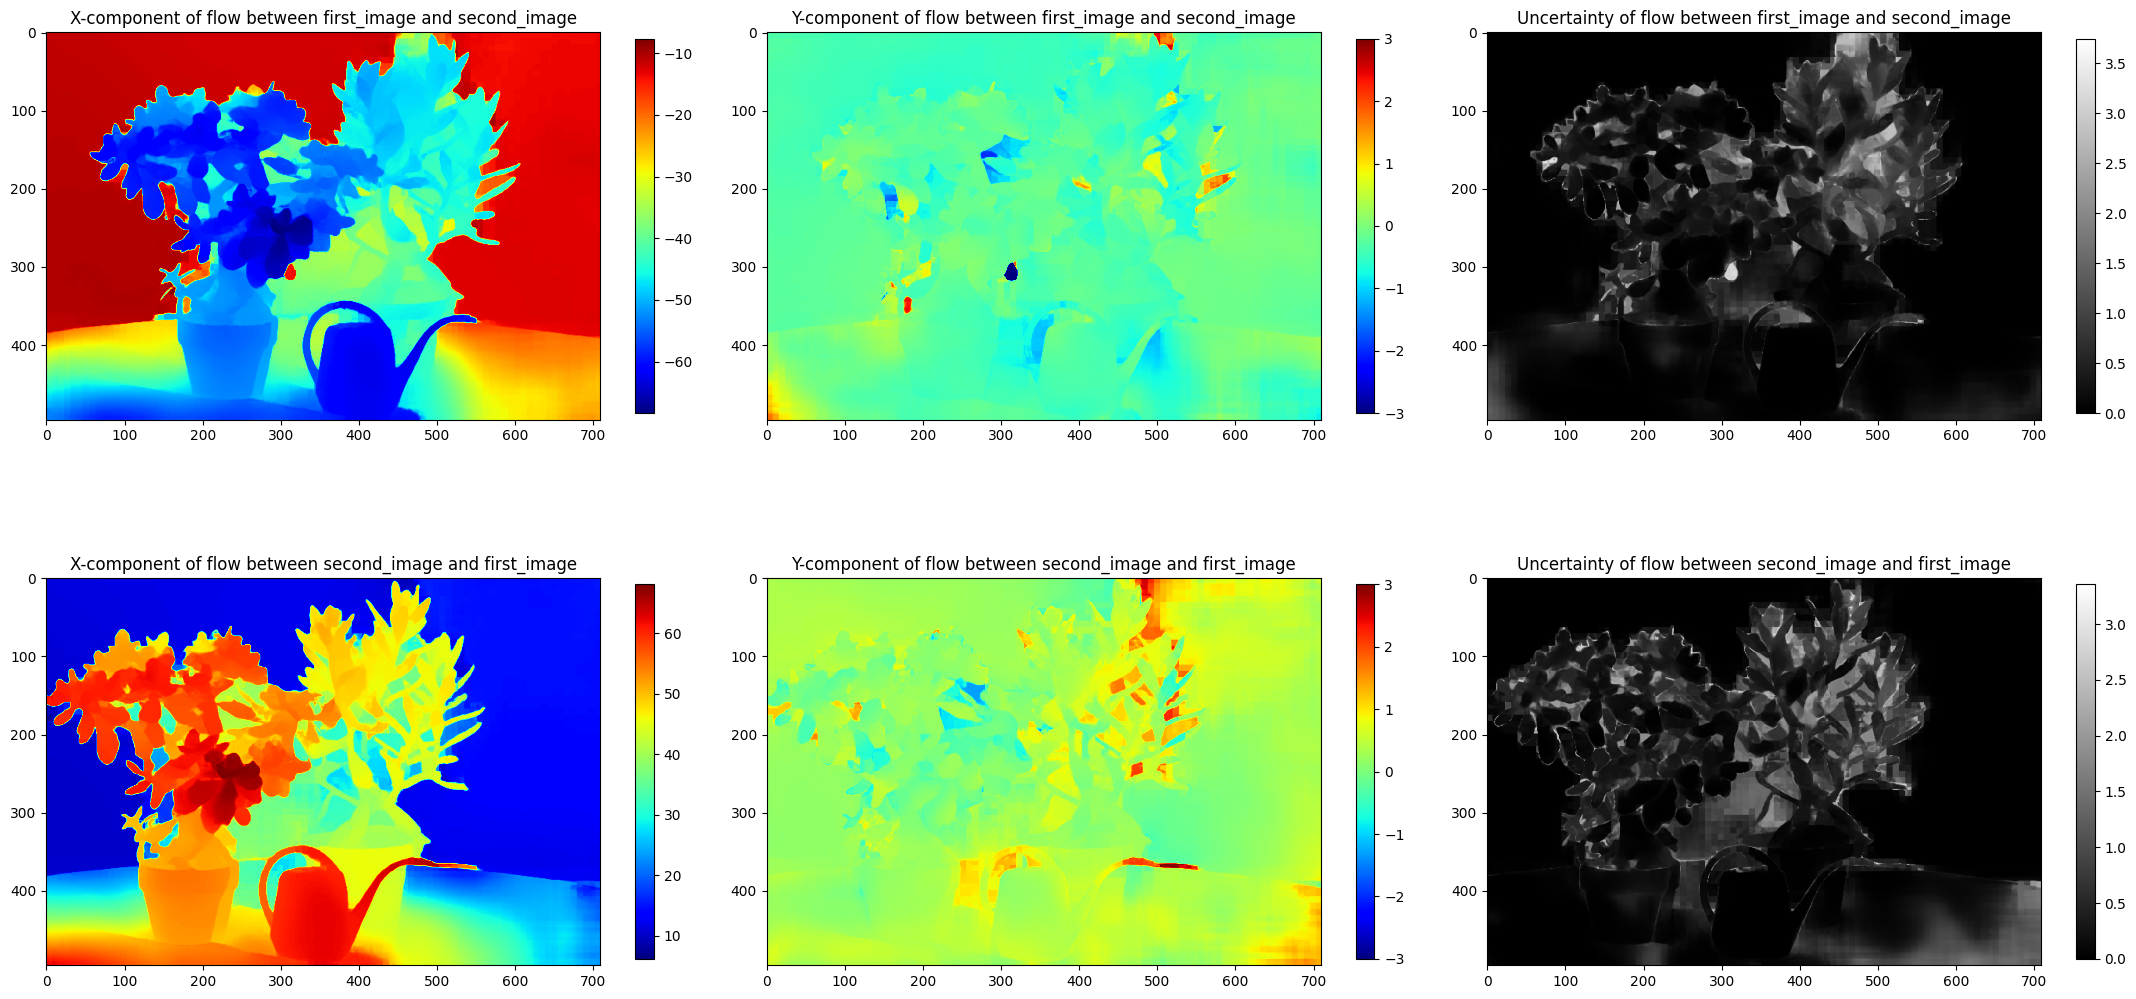

In [13]:
flow_np = flow_result.numpy() # [num_images - 1, H, W, 2]

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

im1 = axes[0, 0].imshow(flow_np[0, ..., 0], cmap='jet')
axes[0, 0].set_title('X-component of flow between first_image and second_image')
plt.colorbar(im1, ax=axes[0, 0], shrink=0.6, aspect=20)

im2 = axes[0, 1].imshow(flow_np[0, ..., 1], cmap='jet', vmin=-3, vmax=3)
axes[0, 1].set_title('Y-component of flow between first_image and second_image')
plt.colorbar(im2, ax=axes[0, 1], shrink=0.6, aspect=20)

uncert12 = axes[0, 2].imshow(flow_uncertainty[0], cmap='gray')
axes[0, 2].set_title('Uncertainty of flow between first_image and second_image')
plt.colorbar(uncert12, ax=axes[0, 2], shrink=0.6, aspect=20)

im3 = axes[1, 0].imshow(flow_np[1, ..., 0], cmap='jet')
axes[1, 0].set_title('X-component of flow between second_image and first_image')
plt.colorbar(im3, ax=axes[1, 0], shrink=0.6, aspect=20)

im4 = axes[1, 1].imshow(flow_np[1, ..., 1], cmap='jet', vmin=-3, vmax=3)
axes[1, 1].set_title('Y-component of flow between second_image and first_image')
plt.colorbar(im4, ax=axes[1, 1], shrink=0.6, aspect=20)

uncert34 = axes[1, 2].imshow(flow_uncertainty[1], cmap='gray')
axes[1, 2].set_title('Uncertainty of flow between second_image and first_image')
plt.colorbar(uncert34, ax=axes[1, 2], shrink=0.6, aspect=20)

plt.tight_layout()
plt.show()